In [46]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [47]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    
    sr:float
    bpb:float
    boundaryPercent:float
    summary:str

In [48]:
def calculate_sr(state:BatsmanState)->dict[str,float]:
    sr = (state['runs']/state['balls'])*100
    
   
    return {'sr':sr}

In [49]:
def calculate_bpb(state:BatsmanState)->dict[str,float]:
    bpb=state['balls']/state['fours']+state['sixes']
   
    return {'bpb':bpb}

In [50]:
def boundaryPercent(state:BatsmanState)->dict[str,float]:
    boundary_percent=(((state['fours']*4)+(state['sixes']*6))/state['runs'])*100
    return {'boundaryPercent':boundary_percent} 

In [51]:
def summary(state:BatsmanState)->BatsmanState:
    summary=f""""
    Strike Rate - {state['sr']}
    Balls per boundary - {state['balls']}
    Boundary Percentage - {state['boundaryPercent']}
    """
    
    state['summary']=summary
    
    return state

In [52]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('boundaryPercent',boundaryPercent)
graph.add_node('summary',summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'boundaryPercent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('boundaryPercent','summary')

graph.add_edge('summary',END)

workflow = graph.compile()

In [ ]:
result = workflow.invoke({'runs':100,'balls':50,'fours':6,'sixes':4})
print(result)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 12.333333333333334, 'boundaryPercent': 48.0, 'summary': '"\n    Strike Rate - 200.0\n    Balls per boundary - 50\n    Boundary Percentage - 48.0\n    '}


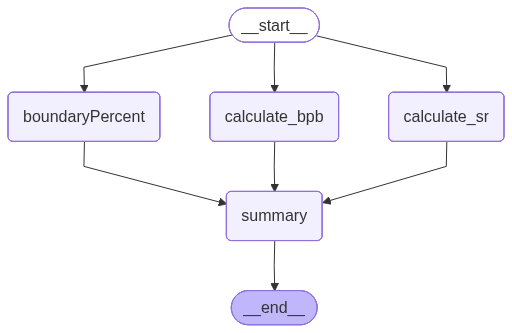

In [54]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())